In [ ]:
#cell 1
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
#cell 2
REAL_VIDEO_DIR = "/content/drive/MyDrive/DeepX video/videos_real"
FAKE_VIDEO_DIR = "/content/drive/MyDrive/DeepX video/videos_fake"


In [ ]:
#cell 3
import os

BASE_DIR = "/content/deepx_video"
FRAME_DIR = os.path.join(BASE_DIR, "frames")

os.makedirs(FRAME_DIR, exist_ok=True)

IMG_SIZE = 299
MAX_FRAMES = 30


In [ ]:
#cell 4
!pip install mtcnn



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 40.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 70.1 MB/s eta 0:00:00


In [ ]:
#cell 5
import cv2
from mtcnn import MTCNN

# Primary detector
detector = MTCNN()

# Fallback detector (GLOBAL)
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)


In [ ]:
def extract_face_frames(video_path, save_dir, fps=5):
    os.makedirs(save_dir, exist_ok=True)
    cap = cv2.VideoCapture(video_path)

    frame_count, saved = 0, 0
    video_fps = int(cap.get(cv2.CAP_PROP_FPS))
    step = max(video_fps // fps, 1)

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        if frame_count % step == 0:
            rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            face = None

            faces = detector.detect_faces(rgb)
            if faces:
                x, y, w, h = faces[0]["box"]
                face = rgb[y:y+h, x:x+w]

            if face is None:
                gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
                haar = face_cascade.detectMultiScale(gray, 1.3, 5)
                if len(haar) > 0:
                    x, y, w, h = haar[0]
                    face = rgb[y:y+h, x:x+w]

            if face is None:
                h, w, _ = rgb.shape
                size = min(h, w) // 2
                cx, cy = w//2, h//2
                face = rgb[cy-size:cy+size, cx-size:cx+size]

            face = cv2.resize(face, (IMG_SIZE, IMG_SIZE))
            cv2.imwrite(os.path.join(save_dir, f"{saved}.jpg"), face)
            saved += 1

        frame_count += 1
        if saved >= MAX_FRAMES:
            break

    cap.release()


In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import Xception

base_cnn = Xception(
    weights="imagenet",
    include_top=False,
    pooling="avg",
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)
base_cnn.trainable = False


83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
import numpy as np

def load_video_features(frame_dir):
    frames = sorted(os.listdir(frame_dir))
    features = []

    for f in frames:
        img = cv2.imread(os.path.join(frame_dir, f))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) / 255.0
        feat = base_cnn.predict(img[np.newaxis], verbose=0)[0]
        features.append(feat)

    while len(features) < MAX_FRAMES:
        features.append(np.zeros(2048))

    return np.array(features[:MAX_FRAMES])


In [ ]:
from tqdm import tqdm
import shutil

def build_dataset():
    X, y = [], []
    for folder, label in [(REAL_VIDEO_DIR, 0), (FAKE_VIDEO_DIR, 1)]:
        for vid in tqdm(os.listdir(folder)):
            vpath = os.path.join(folder, vid)
            fpath = os.path.join(FRAME_DIR, vid)

            extract_face_frames(vpath, fpath)
            if len(os.listdir(fpath)) == 0:
                shutil.rmtree(fpath)
                continue

            X.append(load_video_features(fpath))
            y.append(label)
            shutil.rmtree(fpath)

    return np.array(X), np.array(y)


In [ ]:
X, y = build_dataset()
print(X.shape, y.shape)


100%|██████████| 53/53 [08:59<00:00, 10.18s/it]

(106, 30, 2048) (106,)


In [ ]:
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

inp = Input(shape=(MAX_FRAMES, 2048))
x = LSTM(256)(inp)
x = Dropout(0.5)(x)
x = Dense(64, activation="relu")(x)
out = Dense(1, activation="sigmoid")(x)

model = Model(inp, out)
model.compile(
    optimizer=Adam(1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 30, 2048)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 256)            │     2,360,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,376,833 (9.07 MB)

 Trainable params: 2,376,833 (9.07 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

ckpt = ModelCheckpoint("deepx_video-face.h5", save_best_only=True)
es = EarlyStopping(patience=5, restore_best_weights=True)

model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=25,
    batch_size=4,
    callbacks=[ckpt, es]
)


Epoch 1/25
12/17 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6188 - loss: 0.6777

17/17 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - accuracy: 0.5787 - loss: 0.6849 - val_accuracy: 0.4118 - val_loss: 0.6912
Epoch 2/25
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6238 - loss: 0.6702 - val_accuracy: 0.4118 - val_loss: 0.6919
Epoch 3/25
13/17 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4953 - loss: 0.6851

17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.5133 - loss: 0.6800 - val_accuracy: 0.4706 - val_loss: 0.6856
Epoch 4/25
13/17 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5683 - loss: 0.6692

17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.5834 - loss: 0.6651 - val_accuracy: 0.6471 - val_loss: 0.6611
Epoch 5/25
13/17 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7854 - loss: 0.5982

17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7821 - loss: 0.5943 - val_accuracy: 0.7059 - val_loss: 0.5629
Epoch 6/25
15/17 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7802 - loss: 0.4767

17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7823 - loss: 0.4826 - val_accuracy: 0.7059 - val_loss: 0.5272
Epoch 7/25
15/17 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9202 - loss: 0.3129

17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9183 - loss: 0.3130 - val_accuracy: 0.7647 - val_loss: 0.4496
Epoch 8/25
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8140 - loss: 0.4103 - val_accuracy: 0.6471 - val_loss: 0.6434
Epoch 9/25
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9048 - loss: 0.2990 - val_accuracy: 0.7059 - val_loss: 0.5182
Epoch 10/25
14/17 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9113 - loss: 0.2174

17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9138 - loss: 0.2208 - val_accuracy: 0.8824 - val_loss: 0.3677
Epoch 11/25
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9588 - loss: 0.1519 - val_accuracy: 0.7647 - val_loss: 0.3732
Epoch 12/25
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9791 - loss: 0.1087 - val_accuracy: 0.8235 - val_loss: 0.7085
Epoch 13/25
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9251 - loss: 0.2364 - val_accuracy: 0.8824 - val_loss: 0.3797
Epoch 14/25
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9956 - loss: 0.0466 - val_accuracy: 0.8235 - val_loss: 0.4184
Epoch 15/25
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 1.0000 - loss: 0.0286 - val_accuracy: 0.7647 - val_loss: 0.5070


In [ ]:
from sklearn.metrics import classification_report, roc_auc_score

preds = model.predict(X_test)
print(classification_report(y_test, (preds > 0.5).astype(int)))
print("ROC-AUC:", roc_auc_score(y_test, preds))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
              precision    recall  f1-score   support

           0       0.83      0.91      0.87        11
           1       0.90      0.82      0.86        11

    accuracy                           0.86        22
   macro avg       0.87      0.86      0.86        22
weighted avg       0.87      0.86      0.86        22

ROC-AUC: 0.9256198347107437


In [ ]:
def gradcam_cnn(img_rgb, cnn, layer_name="block14_sepconv2_act"):
    grad_model = tf.keras.models.Model(
        cnn.input,
        [cnn.get_layer(layer_name).output, cnn.output]
    )

    img = img_rgb / 255.0
    img = tf.expand_dims(img, axis=0)

    with tf.GradientTape() as tape:
        conv_out, preds = grad_model(img)
        loss = tf.reduce_mean(preds)

    grads = tape.gradient(loss, conv_out)
    weights = tf.reduce_mean(grads, axis=(0,1,2))

    cam = tf.reduce_sum(conv_out[0] * weights, axis=-1)
    cam = tf.maximum(cam, 0)
    cam /= tf.reduce_max(cam) + 1e-8

    return cam.numpy()


In [ ]:
def overlay_cam(img, cam, alpha=0.5):
    cam = cv2.resize(cam, (img.shape[1], img.shape[0]))
    cam = np.uint8(255 * cam)
    cam = cv2.applyColorMap(cam, cv2.COLORMAP_JET)
    cam = cv2.cvtColor(cam, cv2.COLOR_BGR2RGB)
    return cv2.addWeighted(img, 1-alpha, cam, alpha, 0)


In [ ]:
import matplotlib.pyplot as plt

def explain_video(video_path, top_k=3):
    temp = "/content/explain"
    extract_face_frames(video_path, temp)

    frames = sorted(os.listdir(temp))[:top_k]
    for f in frames:
        img = cv2.imread(os.path.join(temp, f))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        cam = gradcam_cnn(img, base_cnn)
        overlay = overlay_cam(img, cam)

        plt.figure(figsize=(8,4))
        plt.subplot(1,2,1); plt.imshow(img); plt.title("Face"); plt.axis("off")
        plt.subplot(1,2,2); plt.imshow(overlay); plt.title("CNN Grad-CAM"); plt.axis("off")
        plt.show()

    shutil.rmtree(temp)


In [ ]:
from google.colab import files

uploaded = files.upload()
video_path = "/content/" + list(uploaded.keys())[0]

print("✅ Video uploaded:", video_path)


Saving 01__talking_against_wall.mp4 to 01__talking_against_wall.mp4
✅ Video uploaded: /content/01__talking_against_wall.mp4


In [ ]:
def predict_uploaded_video(video_path):
    temp_dir = "/content/test_frames"
    extract_face_frames(video_path, temp_dir)

    if len(os.listdir(temp_dir)) == 0:
        return "NO FACE DETECTED", 0.0

    features = load_video_features(temp_dir)
    pred = model.predict(features[np.newaxis], verbose=0)[0][0]

    label = "DEEPFAKE" if pred > 0.5 else "REAL"
    confidence = pred if label == "DEEPFAKE" else (1 - pred)

    shutil.rmtree(temp_dir)
    return label, float(confidence)


In [ ]:
label, confidence = predict_uploaded_video(video_path)

print("📌 Prediction:", label)
print("📊 Confidence:", round(confidence * 100, 2), "%")


📌 Prediction: DEEPFAKE
📊 Confidence: 56.26 %


In [ ]:
EXPLAIN_DIR = "/content/explain_frames"

# Clean old folder if exists
if os.path.exists(EXPLAIN_DIR):
    shutil.rmtree(EXPLAIN_DIR)

# Extract frames again
extract_face_frames(
    "/content/01__talking_against_wall.mp4",   # or your uploaded video path
    EXPLAIN_DIR
)

print("Frames extracted:", len(os.listdir(EXPLAIN_DIR)))


Frames extracted: 30


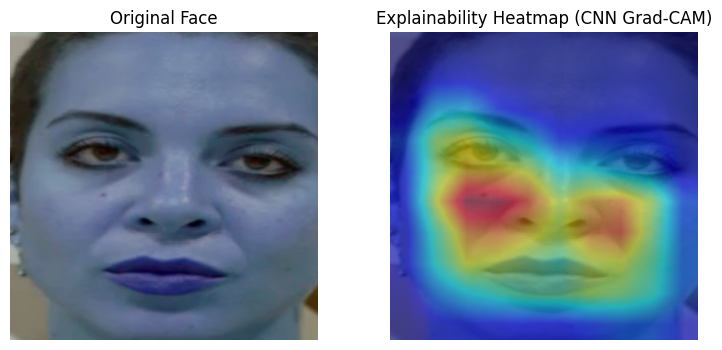

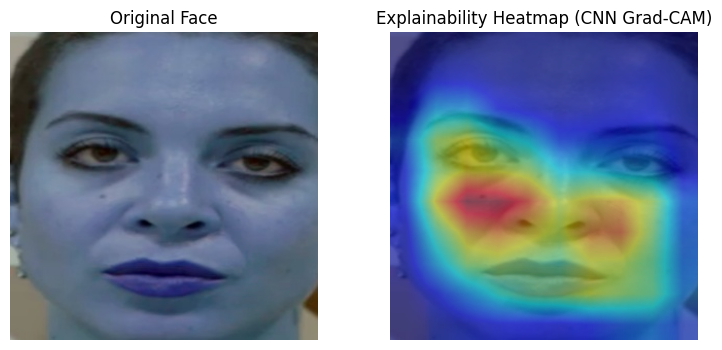

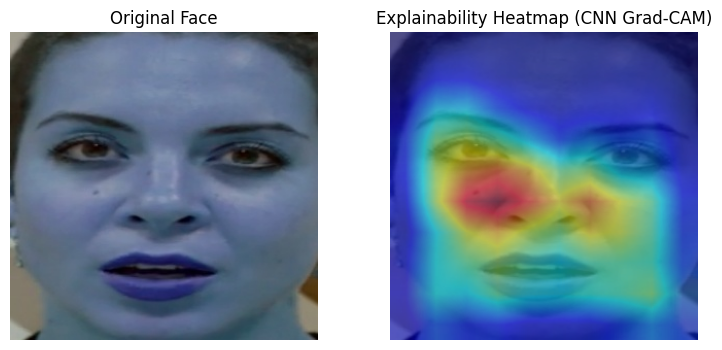

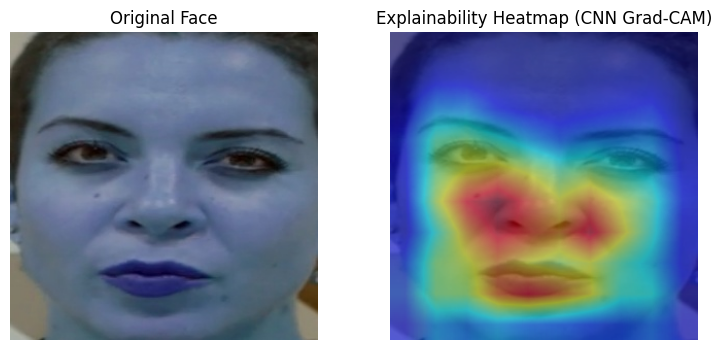

In [ ]:
import os
import cv2
import matplotlib.pyplot as plt

# Step 1: make sure explain directory exists
EXPLAIN_DIR = "/content/explain_frames"

# Step 2: list frames (THIS WAS MISSING)
frames = sorted(os.listdir(EXPLAIN_DIR))

# OPTIONAL: limit to only 4 frames (good for presentation)
frames = frames[:4]

# Step 3: loop
for frame_name in frames:
    img = cv2.imread(os.path.join(EXPLAIN_DIR, frame_name))

    # Safety check (very important)
    if img is None:
        print("❌ Could not read:", frame_name)
        continue

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    cam = gradcam_cnn(img_rgb, base_cnn)
    overlay = overlay_cam(img_rgb, cam)

    plt.figure(figsize=(9,4))

    plt.subplot(1,2,1)
    plt.title("Original Face")
    plt.imshow(img_rgb)
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.title("Explainability Heatmap (CNN Grad-CAM)")
    plt.imshow(overlay)
    plt.axis("off")

    plt.show()


In [ ]:
import shutil
shutil.rmtree(EXPLAIN_DIR)